# K Means

In [67]:
import pickle
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pickle
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

## Cargado de datos

In [ ]:
with open('../data/processed/k-mean-X.pkl', 'rb') as file:
    df = pickle.load(file)

>El Dataframe leido X lo llamaremos df ya que le añadiremos la futura variable objetivo cluster y dejaría de ser X para volver a ser df

## Modelado K-Means

In [69]:
kmeans = KMeans(6, random_state=25)
df['cluster'] = kmeans.fit_predict(df)
df

,MedInc,Latitude,Longitude,cluster
0,2.197582,0.957672,-0.986807,0
1,2.186664,0.952381,-0.984169,0
2,1.707732,0.949735,-0.989446,0
3,0.967177,0.949735,-0.992084,0
4,0.142854,0.949735,-0.992084,2
...,...,...,...,...
20635,-0.905796,1.380952,-0.686016,2
20636,-0.448655,1.383598,-0.717678,2
20637,-0.841709,1.367725,-0.720317,2
20638,-0.765007,1.367725,-0.746702,2


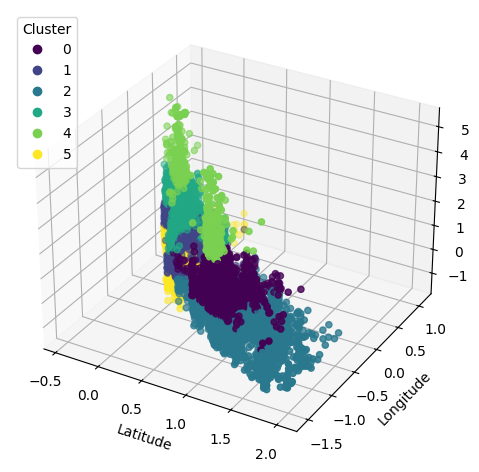

In [70]:
plot = plt.figure().add_subplot(projection='3d')
scatter = plot.scatter(df['Latitude'], df['Longitude'], df['MedInc'], c=df['cluster'])
plot.set_xlabel('Latitude')
plot.set_ylabel('Longitude')
plot.set_zlabel('MedInc')
legend = plot.legend(*scatter.legend_elements(), title="Cluster", loc='upper left')


plt.tight_layout()
plt.show()

## Modelado Supervisado

>Utilizaré random forest como modelo supervisado para tratar de predecir la parte que me quede tras el split

In [71]:
X = df.drop('cluster', axis=1)
y = df['cluster']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=25)
X_train

,MedInc,Latitude,Longitude
5564,0.138725,-0.092593,0.052770
3401,-0.183453,0.002646,0.042216
12334,0.232539,-0.074074,0.525066
18112,0.894282,0.804233,-0.934037
19035,-0.655137,1.084656,-0.920844
...,...,...,...
7324,-0.546093,-0.074074,0.081794
1160,-0.259651,1.391534,-0.802111
1175,-1.243021,1.380952,-0.812665
2934,-0.842581,0.291005,-0.129288


In [72]:
model = RandomForestClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred

array([2, 5, 1, ..., 2, 1, 1], shape=(5160,), dtype=int32)

In [73]:
model_accuracy = accuracy_score(y_test, y_pred)
model_accuracy

0.9951550387596899

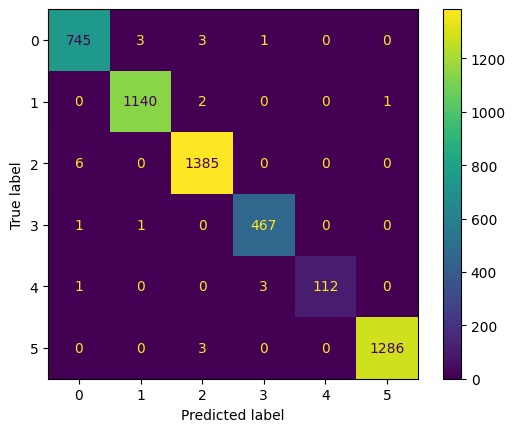

In [74]:
model_confusion_matrix = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(model_confusion_matrix).plot()
plt.show()

In [75]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       752
           1       1.00      1.00      1.00      1143
           2       0.99      1.00      0.99      1391
           3       0.99      1.00      0.99       469
           4       1.00      0.97      0.98       116
           5       1.00      1.00      1.00      1289

    accuracy                           1.00      5160
   macro avg       1.00      0.99      0.99      5160
weighted avg       1.00      1.00      1.00      5160



>El modelo inicial era dificilmente mejorable ya que tenía una precisión mayor a 0.995 por lo tanto no considero necesaria una optimización de este ya que es suficicentemente preciso con los datos que tenemos

## Guardado del modelo

In [ ]:
with open('../models/k-means.pkl', 'wb') as file:
    pickle.dump(kmeans, file)   

with open('../models/k-means-random-forest.pkl', 'wb') as file:
    pickle.dump(model, file)